# 01 — Exploración de datos: Topic `casamarket.documento.detectado`

> **Objetivo**: Leer todos los eventos del topic Kafka, parsear el JSON,
> analizar patrones de uso y detectar anomalías con visualizaciones avanzadas.

## ¿Qué haremos en este notebook?
| Sección | Análisis | Por qué |
|---------|----------|---------|
| 1–3 | Setup + Leer Kafka + Parsear JSON | Base del pipeline de análisis |
| 4–7 | Por extensión, fecha, usuario y estado | EDA descriptivo estándar |
| **8** | **Latencia de procesamiento** | **Detectar cuellos de botella por tipo de doc** |
| **9** | **Heatmap hora × día de semana** | **Identificar picos de actividad real** |
| **10** | **Tasa de errores en el tiempo** | **Monitorear calidad del pipeline** |
| **11** | **Dashboard ejecutivo multi-panel** | **Visión consolidada para presentación** |
| 12 | Streaming en tiempo real | Escuchar eventos nuevos mientras corre el producer |

## Stack
- **PySpark**: leer Kafka en batch y en streaming, parsear JSON, aggregaciones
- **Matplotlib + Seaborn**: visualizaciones, heatmap de actividad, dashboard

| Servicio | URL |
|----------|-----|
| JupyterLab | http://localhost:8888 (token: `casamarket`) |
| Kafka UI | http://localhost:18085 |
| Spark UI | http://localhost:4040 (activo tras crear la sesión) |

## 1. Crear SparkSession

In [1]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("CasaMarket-Explorador")
    .config("spark.ui.port", "4040")
    .config("spark.sql.shuffle.partitions", "4")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print(f"Spark {spark.version} listo — UI: http://localhost:4040")

Spark 3.5.0 listo — UI: http://localhost:4040


## 2. Leer todos los mensajes del topic (batch mode)

In [2]:
KAFKA_BROKER = "ec-kafka:9092"
TOPIC        = "casamarket.documento.detectado"

df_raw = (
    spark.read
    .format("kafka")
    .option("kafka.bootstrap.servers", KAFKA_BROKER)
    .option("subscribe", TOPIC)
    .option("startingOffsets", "earliest")
    .load()
)

print(f"Mensajes en el topic: {df_raw.count()}")
df_raw.printSchema()

Mensajes en el topic: 134
root
 |-- key: binary (nullable = true)
 |-- value: binary (nullable = true)
 |-- topic: string (nullable = true)
 |-- partition: integer (nullable = true)
 |-- offset: long (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- timestampType: integer (nullable = true)



## 3. Parsear JSON y definir schema

In [3]:
from pyspark.sql.functions import from_json, col, to_date, to_timestamp
from pyspark.sql.types import StructType, StructField, StringType, LongType

schema_doc = StructType([
    StructField("id",           LongType(),   True),
    StructField("filename",     StringType(), True),
    StructField("extension",    StringType(), True),
    StructField("status",       StringType(), True),
    StructField("url_file",     StringType(), True),
    StructField("created_at",   StringType(), True),
    StructField("usuario",      StringType(), True),
    StructField("detectado_en", StringType(), True),
])

df = (
    df_raw
    .select(from_json(col("value").cast("string"), schema_doc).alias("d"))
    .select("d.*")
    .withColumn("fecha",       to_date(col("created_at")))
    .withColumn("detectado_ts", to_timestamp(col("detectado_en")))
)

df.printSchema()
df.show(5, truncate=60)

root
 |-- id: long (nullable = true)
 |-- filename: string (nullable = true)
 |-- extension: string (nullable = true)
 |-- status: string (nullable = true)
 |-- url_file: string (nullable = true)
 |-- created_at: string (nullable = true)
 |-- usuario: string (nullable = true)
 |-- detectado_en: string (nullable = true)
 |-- fecha: date (nullable = true)
 |-- detectado_ts: timestamp (nullable = true)

+------+------------------------------------------------------------+---------+----------+------------------------------------------------------------+------------------------+----------------+--------------------------------+----------+--------------------------+
|    id|                                                    filename|extension|    status|                                                    url_file|              created_at|         usuario|                    detectado_en|     fecha|              detectado_ts|
+------+----------------------------------------------------------

## 4. Análisis: documentos por extensión

In [4]:
from pyspark.sql.functions import count

por_extension = (
    df.groupBy("extension")
    .agg(count("*").alias("total"))
    .orderBy(col("total").desc())
)

print("=== Documentos por extensión ===")
por_extension.show(20)

=== Documentos por extensión ===
+---------+-----+
|extension|total|
+---------+-----+
|      pdf|   67|
|     html|   64|
|     xlsx|    3|
+---------+-----+



## 5. Análisis: documentos por fecha

In [5]:
por_fecha = (
    df.groupBy("fecha")
    .agg(count("*").alias("total"))
    .orderBy("fecha", ascending=False)
)

print("=== Documentos por fecha (últimas) ===")
por_fecha.show(30)

=== Documentos por fecha (últimas) ===
+----------+-----+
|     fecha|total|
+----------+-----+
|2026-06-29|    6|
|2026-06-27|    6|
|2026-06-26|    6|
|2026-06-25|    7|
|2026-06-24|    6|
|2026-06-23|    4|
|2026-06-22|    2|
|2026-06-20|    4|
|2026-06-19|    6|
|2026-06-17|   12|
|2026-06-16|    6|
|2026-06-15|    4|
|2026-06-13|    4|
|2026-06-12|    9|
|2026-06-11|    6|
|2026-06-10|    6|
|2026-06-09|    4|
|2026-06-08|    6|
|2026-06-06|    6|
|2026-06-05|    6|
|2026-06-04|    8|
|2026-06-03|    9|
|2026-06-02|    1|
+----------+-----+



## 6. Análisis: documentos por usuario

In [6]:
por_usuario = (
    df.groupBy("usuario")
    .agg(count("*").alias("total"))
    .orderBy(col("total").desc())
)

print("=== Documentos por usuario ===")
por_usuario.show(30, truncate=50)

=== Documentos por usuario ===
+----------------+-----+
|         usuario|total|
+----------------+-----+
|Admin1@tomas.com|  134|
+----------------+-----+



## 7. Análisis: documentos por estado

In [7]:
por_status = (
    df.groupBy("status")
    .agg(count("*").alias("total"))
    .orderBy(col("total").desc())
)

print("=== Documentos por estado ===")
por_status.show()

=== Documentos por estado ===
+----------+-----+
|    status|total|
+----------+-----+
|Finalizado|  134|
+----------+-----+



## 8. Análisis de Latencia de Procesamiento

### ¿Qué medimos?
La **latencia** es el tiempo transcurrido entre que un documento fue **creado** (`created_at`)
y cuando el pipeline lo **detectó y publicó en Kafka** (`detectado_en`).

```
created_at ──────────────────────────────► detectado_en
   │                                             │
   │     latencia = detectado_en - created_at    │
   └─────────────── Δ minutos ─────────────────► │
```

### ¿Por qué importa?
Comparar la latencia **por tipo de extensión** permite identificar:
- Si los PDF tardan más que los HTML en procesarse (diferente parser o peso del archivo)
- Si existe un cuello de botella que afecta solo a ciertos formatos
- Alertas: si la latencia de algún tipo supera un umbral (e.g. > 2 horas)

### Colores del gráfico
| Color | Significado |
|-------|-------------|
| Verde | Latencia < 60 min (aceptable) |
| Naranja | Latencia 60–120 min (revisar) |
| Rojo | Latencia > 120 min (alerta) |

=== Latencia promedio de procesamiento por tipo de documento ===
extension  latencia_promedio_min  total_docs
     html                 555.04           9
      pdf                 559.89           9


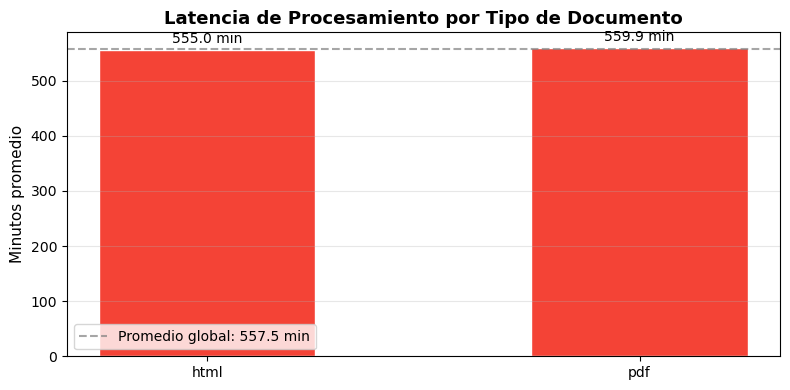

Guardado → output/latencia_procesamiento.png


In [8]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import unix_timestamp, avg as spark_avg, round as spark_round

# Latencia = tiempo entre que se creó el doc (created_at) y cuando lo detectó el pipeline (detectado_en)
# Usamos unix_timestamp para convertir timestamps a segundos y restar directamente
df_lat = (
    df
    .filter(col("detectado_ts").isNotNull() & col("created_at").isNotNull())
    .withColumn("created_ts", to_timestamp(col("created_at")))
    .withColumn(
        "latencia_min",
        (unix_timestamp("detectado_ts") - unix_timestamp("created_ts")) / 60.0
    )
    # Filtrar outliers: descartar negativos (error de timezone) y mayores a 24h
    .filter((col("latencia_min") >= 0) & (col("latencia_min") < 1440))
)

lat_por_ext = (
    df_lat.groupBy("extension")
    .agg(
        spark_round(spark_avg("latencia_min"), 2).alias("latencia_promedio_min"),
        count("*").alias("total_docs")
    )
    .orderBy("latencia_promedio_min")
    .toPandas()
)

print("=== Latencia promedio de procesamiento por tipo de documento ===")
print(lat_por_ext.to_string(index=False))

# Gráfico de barras de latencia
fig, ax = plt.subplots(figsize=(8, 4))
colores_lat = ["#4CAF50" if v < 60 else "#FF9800" if v < 120 else "#F44336"
               for v in lat_por_ext["latencia_promedio_min"]]
bars = ax.bar(lat_por_ext["extension"], lat_por_ext["latencia_promedio_min"],
              color=colores_lat, edgecolor="white", width=0.5)
ax.bar_label(bars, fmt="%.1f min", padding=3)
ax.set_ylabel("Minutos promedio", fontsize=11)
ax.set_title("Latencia de Procesamiento por Tipo de Documento", fontsize=13, fontweight="bold")
ax.axhline(lat_por_ext["latencia_promedio_min"].mean(), color="gray", linestyle="--", alpha=0.7,
           label=f"Promedio global: {lat_por_ext['latencia_promedio_min'].mean():.1f} min")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("/home/jovyan/output/latencia_procesamiento.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado → output/latencia_procesamiento.png")

## 9. Heatmap de Actividad por Hora y Día de Semana

### ¿Qué visualizamos?
Un **heatmap** (mapa de calor) donde:
- Eje X → hora del día (0–23)
- Eje Y → día de la semana (Lun–Dom)
- Color → cantidad de documentos detectados en ese bloque

### ¿Por qué usar un heatmap y no una tabla?
El heatmap permite detectar **patrones visuales de forma inmediata** que una tabla de números
no haría evidente. En segundos se puede responder:
- ¿A qué hora hay más documentos? (columna más oscura)
- ¿Qué días son más activos? (fila más oscura)
- ¿Hay una franja horaria inactiva donde hacer mantenimiento? (filas/columnas blancas)

> **Colormap YlOrRd** (Amarillo→Naranja→Rojo): blanco/amarillo = pocos docs; rojo oscuro = máxima actividad

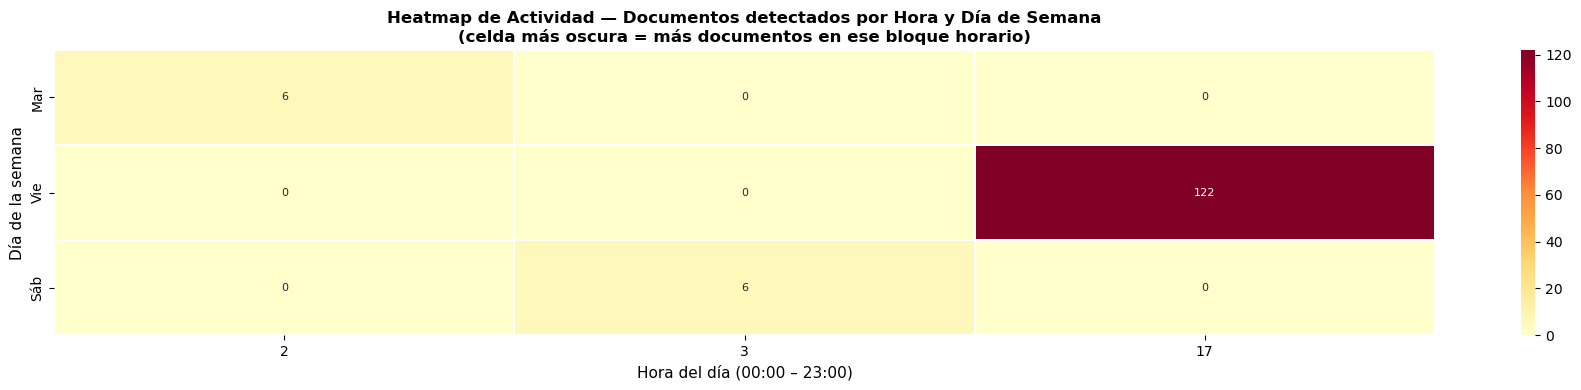

Pico de actividad: Vie a las 17:00 (122 documentos)
Guardado → output/heatmap_actividad.png


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.sql.functions import hour, dayofweek

# Extraer hora y día de semana del timestamp de detección
df_horario = (
    df
    .filter(col("detectado_ts").isNotNull())
    .withColumn("hora",    hour("detectado_ts"))
    .withColumn("dia_sem", dayofweek("detectado_ts"))  # 1=Dom, 2=Lun, ..., 7=Sáb
)

actividad = (
    df_horario.groupBy("dia_sem", "hora")
    .agg(count("*").alias("total"))
    .toPandas()
)

# Convertir números a nombres de día y ordenar de Lun a Dom
dias_map   = {1: "Dom", 2: "Lun", 3: "Mar", 4: "Mié", 5: "Jue", 6: "Vie", 7: "Sáb"}
dias_orden = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
actividad["dia_nombre"] = actividad["dia_sem"].map(dias_map)

# Pivotar: filas = días, columnas = horas (0-23)
pivot = actividad.pivot_table(
    index="dia_nombre", columns="hora", values="total", fill_value=0
)
pivot = pivot.reindex([d for d in dias_orden if d in pivot.index])

fig, ax = plt.subplots(figsize=(18, 4))
sns.heatmap(
    pivot, cmap="YlOrRd",
    annot=True, fmt=".0f",
    linewidths=0.3, linecolor="white",
    ax=ax, annot_kws={"size": 8}
)
ax.set_xlabel("Hora del día (00:00 – 23:00)", fontsize=11)
ax.set_ylabel("Día de la semana", fontsize=11)
ax.set_title(
    "Heatmap de Actividad — Documentos detectados por Hora y Día de Semana\n"
    "(celda más oscura = más documentos en ese bloque horario)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("/home/jovyan/output/heatmap_actividad.png", dpi=150, bbox_inches="tight")
plt.show()

# Identificar el pico de actividad
idx_max = actividad["total"].idxmax()
print(f"Pico de actividad: {dias_map[int(actividad.loc[idx_max,'dia_sem'])]} "
      f"a las {int(actividad.loc[idx_max,'hora'])}:00 "
      f"({int(actividad.loc[idx_max,'total'])} documentos)")
print("Guardado → output/heatmap_actividad.png")

## 10. Tasa de Errores en el Tiempo

### ¿Qué analizamos?
La proporción de documentos con estado diferente a `Finalizado` respecto al total,
agrupada por fecha de creación del documento.

### ¿Por qué importa?
| Patrón | Posible causa |
|--------|---------------|
| Tasa alta constante | Bug en el pipeline de generación de documentos |
| Pico repentino y aislado | Deploy roto, disco lleno o falla puntual de infraestructura |
| Incremento gradual | Degradación lenta del servicio (memory leak, base de datos sobrecargada) |

> Un sistema sano mantiene la tasa de errores **constante y cercana a 0%**.
> Un pico que aparece y desaparece es un incidente; un incremento sostenido es una tendencia.

### Gráfico dual
- **Barras (azul)**: volumen total de documentos por día → contexto de carga
- **Línea (roja)**: tasa de error % → señal de calidad
- **Línea punteada**: promedio histórico → referencia de normalidad

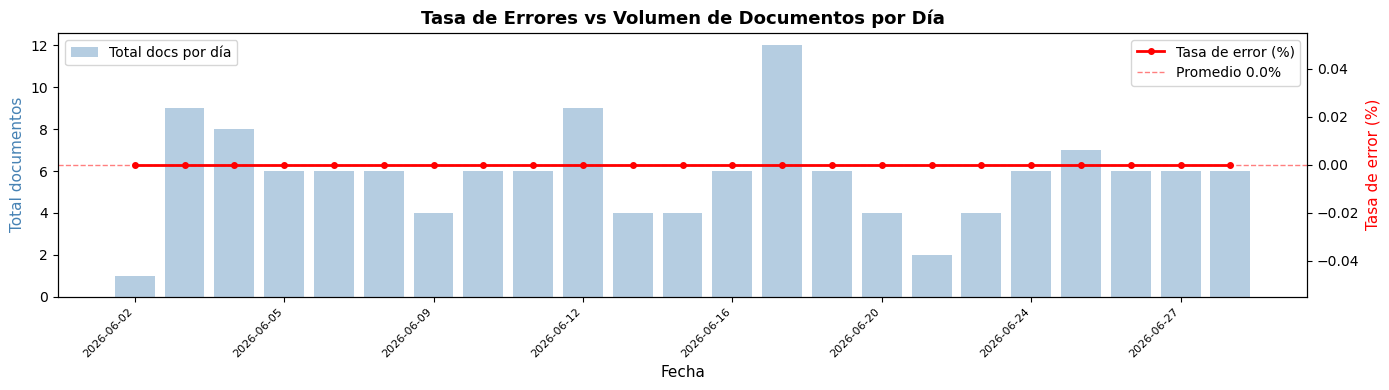

Tasa de error promedio : 0.00%
Tasa de error máxima   : 0.00%
Días sin ningún error  : 23 de 23


In [10]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import when, sum as spark_sum_s

# Errores = cualquier estado que NO sea "Finalizado"
errores_por_fecha = (
    df
    .filter(col("fecha").isNotNull())
    .groupBy("fecha")
    .agg(
        count("*").alias("total"),
        spark_sum_s(when(col("status") != "Finalizado", 1).otherwise(0)).alias("errores")
    )
    .withColumn(
        "tasa_error_pct",
        col("errores") / col("total") * 100
    )
    .orderBy("fecha")
    .toPandas()
)

# ── Gráfico dual: volumen (barras) + tasa de error (línea) ────────────────────
fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()    # segundo eje Y para la tasa de error

ax1.bar(
    range(len(errores_por_fecha)), errores_por_fecha["total"],
    color="steelblue", alpha=0.4, label="Total docs por día"
)
ax2.plot(
    range(len(errores_por_fecha)), errores_por_fecha["tasa_error_pct"],
    color="red", marker="o", linewidth=2, markersize=4, label="Tasa de error (%)"
)
# Línea de promedio de errores (referencia)
media_error = errores_por_fecha["tasa_error_pct"].mean()
ax2.axhline(media_error, color="red", linestyle="--", alpha=0.5, linewidth=1,
            label=f"Promedio {media_error:.1f}%")

step = max(1, len(errores_por_fecha) // 7)
ax1.set_xticks(range(0, len(errores_por_fecha), step))
ax1.set_xticklabels(
    [str(d) for d in errores_por_fecha["fecha"].iloc[::step]], rotation=45, ha="right", fontsize=8
)
ax1.set_xlabel("Fecha", fontsize=11)
ax1.set_ylabel("Total documentos", fontsize=11, color="steelblue")
ax2.set_ylabel("Tasa de error (%)", fontsize=11, color="red")
ax1.set_title(
    "Tasa de Errores vs Volumen de Documentos por Día",
    fontsize=13, fontweight="bold"
)
ax1.legend(loc="upper left"); ax2.legend(loc="upper right")
plt.tight_layout()
plt.savefig("/home/jovyan/output/tasa_errores.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Tasa de error promedio : {media_error:.2f}%")
print(f"Tasa de error máxima   : {errores_por_fecha['tasa_error_pct'].max():.2f}%")
print(f"Días sin ningún error  : {(errores_por_fecha['errores'] == 0).sum()} de {len(errores_por_fecha)}")

## 11. Dashboard Ejecutivo Multi-Panel

Consolida los análisis de las secciones 4, 5, 7 y 8 en **una sola figura** lista para presentar:

| Panel | Contenido | Fuente |
|-------|-----------|--------|
| **A** (arriba izq.) | Documentos por extensión (barras) | `por_extension` |
| **B** (arriba der.) | Tendencia diaria de documentos (línea) | `por_fecha` |
| **C** (abajo izq.) | Estado Finalizado vs Error (donut) | `por_status` |
| **D** (abajo der.) | Latencia promedio por tipo de doc (barras) | `lat_por_ext` |

> Este dashboard es reproducible: basta re-ejecutar las celdas 4, 7, 8 y esta para regenerarlo.

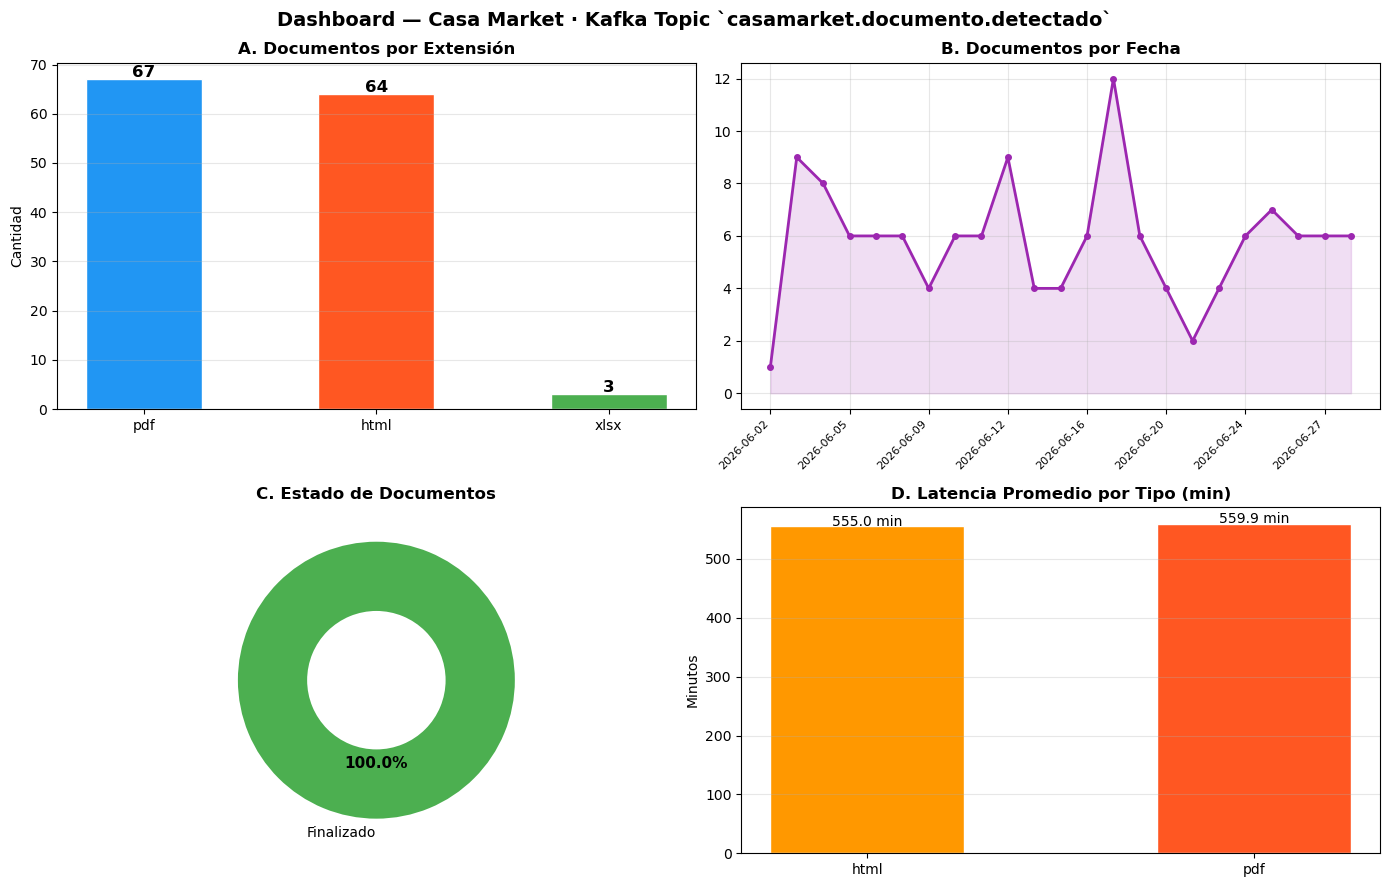

Dashboard guardado → output/dashboard_kafka.png


In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    "Dashboard — Casa Market · Kafka Topic `casamarket.documento.detectado`",
    fontsize=14, fontweight="bold"
)

# ── Panel A: Documentos por extensión ────────────────────────────────────────
ext_pd     = por_extension.toPandas()
colores_a  = ["#2196F3", "#FF5722", "#4CAF50"][:len(ext_pd)]
axes[0, 0].bar(ext_pd["extension"], ext_pd["total"], color=colores_a, edgecolor="white", width=0.5)
for bar, val in zip(axes[0, 0].patches, ext_pd["total"]):
    axes[0, 0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
        str(val), ha="center", fontsize=12, fontweight="bold"
    )
axes[0, 0].set_title("A. Documentos por Extensión", fontweight="bold")
axes[0, 0].set_ylabel("Cantidad")
axes[0, 0].grid(axis="y", alpha=0.3)

# ── Panel B: Tendencia diaria (serie de tiempo) ───────────────────────────────
fecha_pd = por_fecha.toPandas().sort_values("fecha")
axes[0, 1].plot(
    range(len(fecha_pd)), fecha_pd["total"],
    marker="o", color="#9C27B0", linewidth=2, markersize=4
)
axes[0, 1].fill_between(range(len(fecha_pd)), fecha_pd["total"], alpha=0.15, color="#9C27B0")
step = max(1, len(fecha_pd) // 6)
axes[0, 1].set_xticks(range(0, len(fecha_pd), step))
axes[0, 1].set_xticklabels(
    [str(d) for d in fecha_pd["fecha"].iloc[::step]], rotation=45, ha="right", fontsize=8
)
axes[0, 1].set_title("B. Documentos por Fecha", fontweight="bold")
axes[0, 1].grid(alpha=0.3)

# ── Panel C: Estado Finalizado vs Error (donut) ───────────────────────────────
status_pd = por_status.toPandas()
colores_c = ["#4CAF50" if s == "Finalizado" else "#F44336" for s in status_pd["status"]]
wedges, texts, autotexts = axes[1, 0].pie(
    status_pd["total"], labels=status_pd["status"],
    autopct="%1.1f%%", colors=colores_c, startangle=90,
    wedgeprops=dict(width=0.5)   # anillo tipo donut
)
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight("bold")
axes[1, 0].set_title("C. Estado de Documentos", fontweight="bold")

# ── Panel D: Latencia promedio por tipo de documento ─────────────────────────
colores_d = ["#FF9800", "#FF5722", "#FFC107"][:len(lat_por_ext)]
axes[1, 1].bar(lat_por_ext["extension"], lat_por_ext["latencia_promedio_min"],
               color=colores_d, edgecolor="white", width=0.5)
for bar, val in zip(axes[1, 1].patches, lat_por_ext["latencia_promedio_min"]):
    axes[1, 1].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
        f"{val:.1f} min", ha="center", fontsize=10
    )
axes[1, 1].set_title("D. Latencia Promedio por Tipo (min)", fontweight="bold")
axes[1, 1].set_ylabel("Minutos")
axes[1, 1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("/home/jovyan/output/dashboard_kafka.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard guardado → output/dashboard_kafka.png")

## 9. Streaming: escuchar eventos nuevos en tiempo real

> **Nota:** Ejecuta esta celda mientras el producer corre en paralelo.
> Detén la query con el botón ■ Stop o la celda siguiente.

In [12]:
from pyspark.sql.functions import window

stream_raw = (
    spark.readStream
    .format("kafka")
    .option("kafka.bootstrap.servers", KAFKA_BROKER)
    .option("subscribe", TOPIC)
    .option("startingOffsets", "latest")   # solo nuevos
    .load()
)

stream_docs = (
    stream_raw
    .select(from_json(col("value").cast("string"), schema_doc).alias("d"))
    .select("d.*")
    .withColumn("detectado_ts", to_timestamp(col("detectado_en")))
)

query = (
    stream_docs
    .select("id", "filename", "extension", "status", "usuario", "detectado_ts")
    .writeStream
    .outputMode("append")
    .format("console")
    .option("truncate", "false")
    .option("numRows", "20")
    .trigger(processingTime="15 seconds")
    .start()
)

print("Streaming activo — esperando mensajes nuevos (Spark UI: http://localhost:4040)")
print("Ejecuta la celda siguiente para detener.")
query.awaitTermination(timeout=120)

Streaming activo — esperando mensajes nuevos (Spark UI: http://localhost:4040)
Ejecuta la celda siguiente para detener.


False

In [10]:
# Detener el streaming
#query.stop()
#print("Streaming detenido.")